# **Exploring Reviewing Culture in Letterboxd's Top 250 Film Community**

## **Overview**


### **Research Goal**

This project explores linguistic patterns, sentiment expression, and reviewing culture in **Letterboxd's Top 250 film community**.

### **Updated Research Questions**

1. What linguistic features characterize reviews in Letterboxd's Top 250 film community?

2. What themes and topics appear most frequently in these reviews?

3. How do users express sentiment and emotional engagement toward highly regarded films?

4. What do these patterns suggest about the reviewing culture reflected in this corpus?

### **Original Project Design**

The original goal of this project was to compare linguistic patterns between **IMDb and Letterboxd movie reviews**. The project initially aimed to examine differences in review length, vocabulary usage, sentiment, and other textual features across the two platforms. By comparing these linguistic patterns, the project hoped to explore how reviewing practices might differ between online movie-review communities.

During further exploratory analysis, important structural differences between the datasets became apparent.

### **Datasets**

Three datasets were used during different stages of the project:

- IMDb Movie Reviews Dataset (50,000 reviews)
>Source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- Letterboxd Movie Reviews Dataset (90,016 reviews)
>Source: https://www.kaggle.com/datasets/riyosha/letterboxd-movie-reviews-90000
- Letterboxd Movie Metadata Dataset
>Source: https://www.kaggle.com/datasets/ky1338/10000-movies-letterboxd-data

The IMDb and Letterboxd review datasets were initially collected for a cross-platform comparison. Following refinement of the research scope, the primary analyses focused on the **Letterboxd review corpus**. A Letterboxd movie metadata dataset containing information about **film genres and spoken languages** was later incorporated to enrich the analysis.

## **Analysis**

### **Data Loading**
The IMDb and Letterboxd review datasets were loaded during the initial exploratory phase of the project. Because the original research design focused on comparing review corpora, exploratory analyses were conducted using these two review datasets.

The metadata dataset was introduced later, after the research scope was refined and film-level information was incorporated into the project. Its integration is described in a later section.

In [68]:
import pandas as pd

In [69]:
imdb = pd.read_csv("../data/IMDB Dataset.csv")
letterboxd = pd.read_csv("../data/letterboxd_250movie_reviews.csv")



In [70]:
print(imdb.shape)
print(letterboxd.shape)

(50000, 2)
(90016, 6)


In [71]:
imdb.columns


Index(['review', 'sentiment'], dtype='str')

In [72]:
letterboxd.columns

Index(['Unnamed: 0', 'Review', 'Rating', 'Date', 'Status', 'Movie'], dtype='str')

In [73]:
imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [74]:
letterboxd.head()

,Unnamed: 0,Review,Rating,Date,Status,Movie
0,0,I am an idiot. Why is it that I still dread wa...,★★★★★,01 Dec 2013,Watched,harakiri
1,1,honor in the individual is virtue honor in a s...,★★★★★,18 Jan 2022,NaN,harakiri
2,2,Brilliant. Riveting exploration of mortality a...,NaN,26 Jan 2024,Watched,harakiri
3,3,God damn what an impeccable film. Not dated in...,★★★★★,21 Jun 2021,Watched,harakiri
4,4,95First thing's first: giving a big thanks to ...,★★★★★,06 Sep 2020,Watched,harakiri


### **Exploratory Data Analysis**

#### **Dataset Overview**

This section provides an initial exploration of the IMDb and Letterboxd datasets, including dataset size, data completeness, and rating distributions.

The purpose is to better understand the structure and quality of the data before conducting linguistic analysis.

In [75]:
print("IMDb Dataset")
imdb.info()

print("\n" + "="*50 + "\n")

print("Letterboxd Dataset")
letterboxd.info()

IMDb Dataset
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


Letterboxd Dataset
<class 'pandas.DataFrame'>
RangeIndex: 90016 entries, 0 to 90015
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  90016 non-null  int64
 1   Review      90011 non-null  str  
 2   Rating      86513 non-null  str  
 3   Date        90016 non-null  str  
 4   Status      86858 non-null  str  
 5   Movie       90016 non-null  str  
dtypes: int64(1), str(5)
memory usage: 96.6 MB


#### **Missing Values**

In [76]:
print("IMDb Reviews:", len(imdb))

print("Letterboxd Reviews:", len(letterboxd))

print()

print("Missing Reviews:", letterboxd["Review"].isna().sum())

print("Missing Ratings:", letterboxd["Rating"].isna().sum())

print("Missing Status:", letterboxd["Status"].isna().sum())

IMDb Reviews: 50000
Letterboxd Reviews: 90016

Missing Reviews: 5
Missing Ratings: 3503
Missing Status: 3158


#### **Rating Distribution**

The distribution of ratings is examined to understand how users evaluate films on Letterboxd and to inform the selection of rating groups for later analysis.

In [77]:
letterboxd["Rating"].value_counts().sort_index()

Rating
½          340
★          320
★½         294
★★         737
★★½        892
★★★       2380
★★★½      4411
★★★★     15031
★★★★½    21031
★★★★★    41077
Name: count, dtype: int64

In [78]:
import matplotlib.pyplot as plt

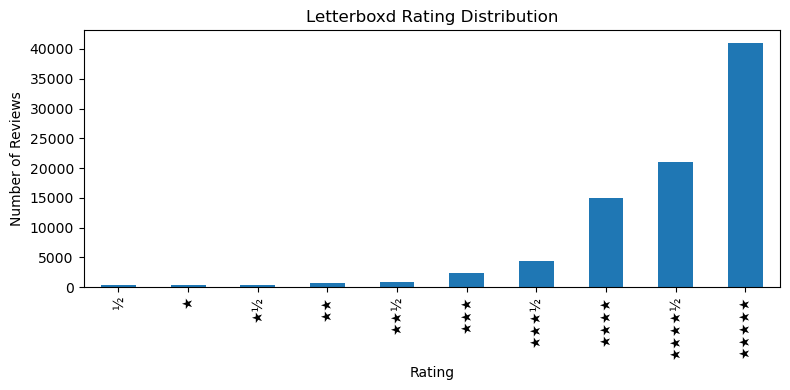

In [79]:
rating_counts = (
    letterboxd["Rating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,4))

rating_counts.plot(kind="bar")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.title("Letterboxd Rating Distribution")

plt.tight_layout()

plt.show()

The rating distribution is heavily **right-skewed**. Most reviews are associated with ratings of four stars or above, while low ratings are relatively rare.

**This pattern is consistent with the fact that the corpus consists of reviews for films from Letterboxd's Top 250 list.**

As a result, sentiment polarity is unlikely to provide a meaningful basis for comparing positive and negative reviews. Instead, subsequent analyses focus on linguistic patterns, themes, and forms of sentiment expression within a predominantly positive reviewing community.

#### **Corpus Characteristics**

In [80]:
letterboxd["Movie"].nunique()
letterboxd["Movie"].value_counts().head(20)

Movie
the-prestige                                    368
apocalypse-now                                  364
se7en                                           364
harakiri                                        360
come-and-see                                    360
12-angry-men                                    360
seven-samurai                                   360
the-godfather-part-ii                           360
high-and-low                                    360
the-human-condition-iii-a-soldiers-prayer       360
the-shawshank-redemption                        360
parasite                                        360
the-godfather                                   360
yi-yi                                           360
city-of-god                                     360
schindlers-list                                 360
ikiru                                           360
the-lord-of-the-rings-the-return-of-the-king    360
la-haine                                        360
the-hu

In [81]:
letterboxd["Movie"].value_counts().describe()

count    250.0000
mean     360.0640
std        0.6176
min      360.0000
25%      360.0000
50%      360.0000
75%      360.0000
max      368.0000
Name: count, dtype: float64

In [82]:
sorted(letterboxd["Movie"].unique())[:50]

['12-angry-men',
 '2001-a-space-odyssey',
 '4-months-3-weeks-and-2-days',
 '8-half',
 'a-brighter-summer-day',
 'a-man-escaped',
 'a-matter-of-life-and-death',
 'a-separation',
 'a-special-day',
 'a-woman-under-the-influence',
 'ace-in-the-hole',
 'aftersun',
 'akira',
 'alien',
 'all-about-eve',
 'all-that-jazz',
 'amadeus',
 'amour',
 'an-autumn-afternoon',
 'an-elephant-sitting-still',
 'anatomy-of-a-murder',
 'andrei-rublev',
 'aparajito',
 'apocalypse-now',
 'apur-sansar',
 'army-of-shadows',
 'autumn-sonata',
 'barry-lyndon',
 'before-sunrise',
 'before-sunset',
 'bicycle-thieves',
 'brief-encounter',
 'casablanca',
 'central-station',
 'children-of-men',
 'children-of-paradise',
 'chinatown',
 'chungking-express',
 'cinema-paradiso',
 'city-lights',
 'city-of-god',
 'close-up',
 'come-and-see',
 'cure',
 'das-boot',
 'dead-poets-society',
 'dersu-uzala',
 'django-unchained',
 'do-the-right-thing',
 'dog-day-afternoon']

Preliminary inspection of the film list suggests that the corpus is dominated by highly acclaimed and canonized films from diverse historical periods, countries, and cinematic traditions.

Examples include 12 Angry Men, 2001: A Space Odyssey, Andrei Rublev, Apocalypse Now, and Do the Right Thing.

This observation further supports the interpretation of the corpus as representing **a film enthusiast community** rather than a general movie-viewing population.

### **Research Direction Adjustment**

The original project proposal aimed to compare linguistic patterns between IMDb and Letterboxd movie reviews.

However, during exploratory data analysis, an important difference between the datasets became apparent. The IMDb dataset contains review texts and sentiment labels but does not include movie-level information. In contrast, the Letterboxd dataset consists of reviews associated with films from the platform's Top 250 list and includes movie titles.

This difference introduces **a methodological challenge**: observed linguistic differences may reflect not only platform-specific reviewing practices but also differences in the films represented in each dataset. As a result, a direct comparison between the two datasets would be difficult to interpret.

Further exploration of the Letterboxd dataset revealed that it contains reviews for 250 highly acclaimed films, with approximately 360 reviews sampled for each film. The corpus therefore represents a relatively balanced collection of reviews drawn from a specific film-reviewing community rather than a random sample of movie reviews.

Following discussions during office hours and further examination of the data, the project was refined to focus on the Letterboxd Top 250 review corpus. Rather than comparing two datasets with substantially different structures, **the revised project investigates linguistic patterns, sentiment expression, recurring themes, and reviewing practices within a single review community.**

To support additional analyses beyond review text alone, **an external movie metadata dataset was incorporated**. This dataset provides information about film genres and spoken languages, enabling review patterns to be examined alongside selected characteristics of the films being discussed.

This adjustment better aligns the research questions with the available data while also creating opportunities to explore how reviewing practices may vary across different types of films within the corpus.


### **Data Preparation**

#### **Data Cleaning**

The following cleaning steps were applied before conducting linguistic analysis:

* Removed the automatically generated index column (`"Unnamed: 0"`).
* Removed reviews with missing `review`.
* Removed reviews with missing `rating` information.
* Retained the `Date`, `Status`, and `Movie` columns for potential later analysis.
* Created a cleaned dataset (`letterboxd_clean`) for subsequent analyses.

After cleaning, the dataset contained **86,508 reviews**, compared to **90,016 reviews** in the original dataset.


In [83]:
letterboxd_clean = letterboxd.copy()

letterboxd_clean = letterboxd_clean.drop(columns=["Unnamed: 0"])

letterboxd_clean.columns

Index(['Review', 'Rating', 'Date', 'Status', 'Movie'], dtype='str')

In [84]:
letterboxd_clean.isna().sum()

Review       5
Rating    3503
Date         0
Status    3158
Movie        0
dtype: int64

In [85]:
letterboxd_clean = letterboxd_clean.dropna(subset=["Review", "Rating"])

In [86]:
print("Original rows:", len(letterboxd))
print("Cleaned rows:", len(letterboxd_clean))

Original rows: 90016
Cleaned rows: 86508


#### **Metadata Integration**

To enrich the Letterboxd review corpus, an additional metadata dataset containing information about film genres and spoken languages was incorporated.

The metadata dataset was merged with the cleaned review corpus using a slug-based matching procedure. Movie titles from both datasets were standardized before matching.

After title standardization and metadata integration, 67,574 reviews across 195 films were successfully matched with metadata records. Although the metadata file did not cover every film in the original Letterboxd corpus, the matched subset remains large enough for subsequent genre and spoken-language analyses.

The resulting dataset enables review patterns to be examined alongside characteristics of the films being discussed, particularly genre classifications and spoken-language groups.

In [87]:
metadata = pd.read_csv("../data/Movie_Data_File.csv")

In [88]:
import re

def make_slug(title):
    title = str(title).lower().strip()
    
    # Remove year suffix, such as "-2023" or "-1983"
    title = re.sub(r"-(19|20)\d{2}$", "", title)
    
    # Standardize special cases
    title = title.replace("&", "and")
    
    # Keep only letters, numbers, spaces, and hyphens
    title = re.sub(r"[^a-z0-9\s-]", "", title)
    
    # Replace spaces with hyphens
    title = re.sub(r"\s+", "-", title)
    
    # Collapse repeated hyphens
    title = re.sub(r"-+", "-", title)
    
    return title.strip("-")

letterboxd_clean["movie_slug"] = letterboxd_clean["Movie"].apply(make_slug)
metadata["movie_slug"] = metadata["Film_title"].apply(make_slug)

metadata_small = metadata[
    ["movie_slug", "Genres", "Spoken_languages"]
].drop_duplicates(subset=["movie_slug"])

merged = letterboxd_clean.merge(
    metadata_small,
    on="movie_slug",
    how="left"
)

merged[["Movie", "Genres", "Spoken_languages"]].head()

,Movie,Genres,Spoken_languages
0,harakiri,"['History', 'Drama', 'Action']",['Japanese']
1,harakiri,"['History', 'Drama', 'Action']",['Japanese']
2,harakiri,"['History', 'Drama', 'Action']",['Japanese']
3,harakiri,"['History', 'Drama', 'Action']",['Japanese']
4,harakiri,"['History', 'Drama', 'Action']",['Japanese']


In [89]:
print("Total reviews:", len(merged))
print("Matched reviews:", merged["Genres"].notna().sum())
print("Match rate:", merged["Genres"].notna().mean())

Total reviews: 86508
Matched reviews: 67574
Match rate: 0.7811300688953623


In [90]:
final_dataset = merged[
    [
        "Review",
        "Rating",
        "Movie",
        "Genres",
        "Spoken_languages"
    ]
].copy()

final_dataset = final_dataset.dropna(
    subset=["Genres", "Spoken_languages"]
)

len(final_dataset)

final_dataset.head()


,Review,Rating,Movie,Genres,Spoken_languages
0,I am an idiot. Why is it that I still dread wa...,★★★★★,harakiri,"['History', 'Drama', 'Action']",['Japanese']
1,honor in the individual is virtue honor in a s...,★★★★★,harakiri,"['History', 'Drama', 'Action']",['Japanese']
2,God damn what an impeccable film. Not dated in...,★★★★★,harakiri,"['History', 'Drama', 'Action']",['Japanese']
3,95First thing's first: giving a big thanks to ...,★★★★★,harakiri,"['History', 'Drama', 'Action']",['Japanese']
4,Probably the greatest film ever.. a film about...,★★★★★,harakiri,"['History', 'Drama', 'Action']",['Japanese']


In [91]:
final_dataset.isna().sum()

Review              0
Rating              0
Movie               0
Genres              0
Spoken_languages    0
dtype: int64

In [92]:
print("Rows:", len(final_dataset))
print("Movies:", final_dataset["Movie"].nunique())

Rows: 67574
Movies: 195


### **Review Length Analysis**

#### **Review Length Distribution**

In [93]:
final_dataset["review_length"] = (
    final_dataset["Review"]
    .str.split()
    .str.len()
)

In [94]:
final_dataset["review_length"].describe()

count    67574.000000
mean       173.935153
std        288.564876
min          1.000000
25%         22.000000
50%         82.000000
75%        217.000000
max      14783.000000
Name: review_length, dtype: float64

In [95]:
import matplotlib.pyplot as plt

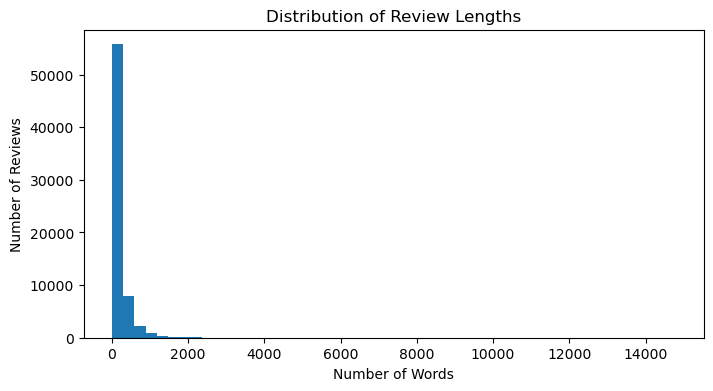

In [96]:
plt.figure(figsize=(8,4))

plt.hist(
    final_dataset["review_length"],
    bins=50
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

In [97]:
final_dataset["review_length"].quantile(
    [0.90,0.95,0.99]
)

0.90     433.00
0.95     632.00
0.99    1201.27
Name: review_length, dtype: float64

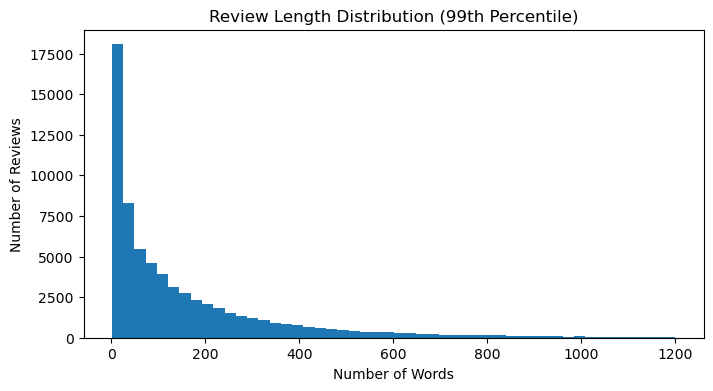

In [98]:
cutoff = final_dataset["review_length"].quantile(0.99)

plt.figure(figsize=(8,4))

plt.hist(
    final_dataset[
        final_dataset["review_length"] <= cutoff
    ]["review_length"],
    bins=50
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Review Length Distribution (99th Percentile)")

plt.show()

Most reviews are relatively short, with the median review containing approximately 84 words. However, a small number of users write substantially longer reviews, producing a long tail in the distribution.

After excluding the top 1% of review lengths for visualization purposes, the overall pattern remains clear: **short and medium-length reviews dominate the corpus, while very long reviews are comparatively rare.**

This suggests that participation in the Letterboxd Top 250 community takes multiple forms, **ranging from brief reactions to extended critical reflections**.

#### **Review Length by Rating**

This section examines whether review length varies across rating categories. Differences in review length may provide insight into how users engage with films and express evaluation on Letterboxd.

In [99]:
sorted(final_dataset["Rating"].unique())

['½', '★', '★½', '★★', '★★½', '★★★', '★★★½', '★★★★', '★★★★½', '★★★★★']

In [100]:
length_by_rating = (
    final_dataset
    .groupby("Rating")["review_length"]
    .mean()
)

length_by_rating

Rating
½        157.951128
★        226.029536
★½       158.955752
★★       176.798978
★★½      175.219061
★★★      159.607688
★★★½     166.493425
★★★★     147.872499
★★★★½    163.741803
★★★★★    189.284229
Name: review_length, dtype: float64

In [101]:
median_length_by_rating = (
    final_dataset
    .groupby("Rating")["review_length"]
    .median()
)

median_length_by_rating

Rating
½        55.0
★        84.0
★½       91.0
★★       89.0
★★½      91.0
★★★      82.0
★★★½     97.0
★★★★     78.0
★★★★½    83.0
★★★★★    81.0
Name: review_length, dtype: float64

**Review length does not vary substantially across rating categories.**

Median review lengths remain relatively stable, generally ranging between 80 and 100 words for most rating levels. Although the lowest-rated reviews tend to be somewhat shorter, the overall differences are modest.

This suggests that rating alone may not strongly influence how much users choose to write. Instead, review length appears to be shaped by other factors beyond simple positive or negative evaluation.

#### **Review Length by Film**

In [102]:
film_length = (
    final_dataset
    .groupby("Movie")["review_length"]
    .mean()
    .sort_values(ascending=False)
)

film_length.head(20)

Movie
satantango                                       440.024922
stalker                                          297.985030
andrei-rublev                                    285.926686
an-elephant-sitting-still                        269.779070
werckmeister-harmonies                           267.597598
vertigo                                          260.060000
2001-a-space-odyssey                             246.977273
solaris                                          244.426471
ran                                              236.282051
ikiru                                            234.253602
the-man-who-shot-liberty-valance                 232.829851
once-upon-a-time-in-the-west                     231.790831
fanny-and-alexander                              230.682997
the-sacrifice                                    230.046512
seven-samurai                                    225.587896
neon-genesis-evangelion-the-end-of-evangelion    224.858859
apocalypse-now                    

In [103]:
film_length.tail(20)

Movie
the-holdovers                       120.821114
the-grand-budapest-hotel            120.782486
spirited-away                       115.943662
dog-day-afternoon                   115.048295
sing-sing-2023                      114.658824
spider-man-into-the-spider-verse    112.246459
portrait-of-a-lady-on-fire          110.617143
heat                                107.142424
the-iron-giant                      106.997118
howls-moving-castle                 101.388571
monster                             101.094556
singin-in-the-rain                  100.632768
good-will-hunting                    99.519886
war-and-peace                        98.217910
the-truman-show                      97.811268
fight-club                           97.082111
fantastic-mr-fox                     89.414773
parasite                             87.709302
dead-poets-society                   79.005698
marcel-the-shell-with-shoes-on       17.042308
Name: review_length, dtype: float64

In [104]:
film_median = (
    final_dataset
    .groupby("Movie")["review_length"]
    .median()
    .sort_values(ascending=False)
)

film_median.head(20)

Movie
satantango                             232.0
an-elephant-sitting-still              166.0
stalker                                153.0
ikiru                                  152.0
andrei-rublev                          148.0
the-life-and-death-of-colonel-blimp    147.0
werckmeister-harmonies                 145.0
the-man-who-shot-liberty-valance       139.0
the-face-of-another                    136.0
la-dolce-vita                          135.5
fanny-and-alexander                    135.0
solaris                                135.0
the-wages-of-fear                      131.0
the-cremator                           130.0
army-of-shadows                        129.0
the-sacrifice                          128.0
once-upon-a-time-in-the-west           127.0
malcolm-x-1992                         126.0
high-and-low                           126.0
mirror                                 126.0
Name: review_length, dtype: float64

In [105]:
film_median.tail(20)

Movie
the-iron-giant                           40.0
howls-moving-castle                      39.0
pulp-fiction                             38.0
the-godfather                            38.0
eternal-sunshine-of-the-spotless-mind    36.0
monster                                  36.0
prisoners                                35.5
war-and-peace                            35.0
portrait-of-a-lady-on-fire               34.0
singin-in-the-rain                       34.0
dog-day-afternoon                        33.5
spider-man-into-the-spider-verse         31.0
the-truman-show                          30.0
good-will-hunting                        29.0
inglourious-basterds                     29.0
fantastic-mr-fox                         23.0
whiplash-2014                            22.0
dead-poets-society                       20.0
fight-club                               18.0
marcel-the-shell-with-shoes-on           10.0
Name: review_length, dtype: float64

Films associated with art-house, slow cinema, and auteur traditions tend to receive longer reviews. Examples include *Satantango*, *Stalker*, *Andrei Rublev*, and *Taste of Cherry*.

In contrast, films such as *Fight Club*, *Whiplash*, *Spider-Man: Into the Spider-Verse*, and *Fantastic Mr. Fox* receive substantially shorter reviews on average.

Since median values are less influenced by extreme outliers, this pattern suggests that longer writing is not driven solely by a small number of unusually long reviews. Rather, certain films appear to encourage more extensive discussion across a broader portion of the reviewing community.

This finding suggests that film-level characteristics may influence review length more strongly than rating alone. One possible explanation is that factors such as genre, narrative style, and other characteristics of individual films shape how extensively viewers choose to engage with them in writing.


#### **Review Length by Genre**

In [106]:
import ast

genre_df = final_dataset.copy()

genre_df["Genres"] = genre_df["Genres"].apply(ast.literal_eval)

genre_df = genre_df.explode("Genres")

In [107]:
genre_length = (
    genre_df.groupby("Genres")["review_length"]
    .median()
    .sort_values(ascending=False)
)

genre_length

Genres
Western            107.0
History            105.0
War                102.0
Mystery             87.0
Drama               86.0
Romance             82.0
Thriller            77.0
Fantasy             76.0
Action              72.0
Crime               72.0
Horror              69.0
Science Fiction     68.0
Comedy              66.0
Adventure           63.5
Music               56.0
Animation           49.0
Family              39.0
Name: review_length, dtype: float64

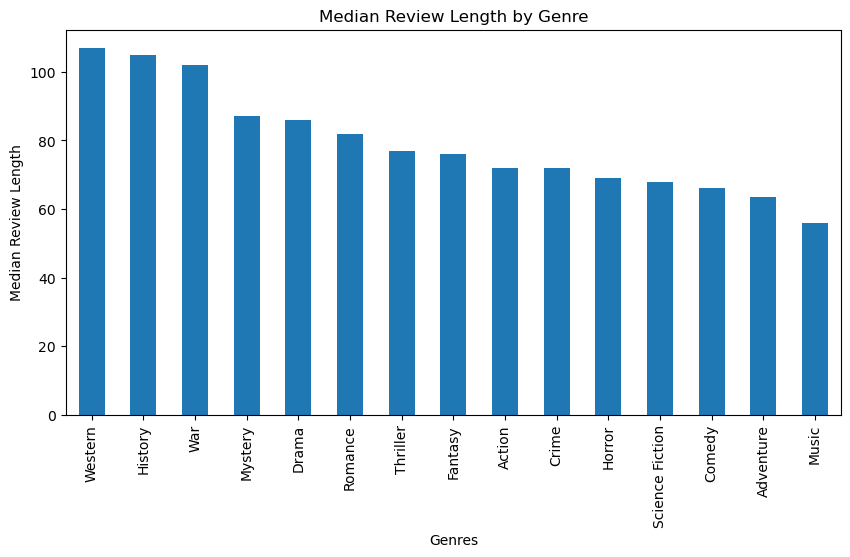

In [108]:
genre_length.head(15).plot.bar(figsize=(10,5))
plt.ylabel("Median Review Length")
plt.title("Median Review Length by Genre")
plt.show()

**Genre Distribution.**

In [109]:
genre_movie_counts = (
    genre_df
    .groupby("Genres")["Movie"]
    .nunique()
    .sort_values(ascending=False)
)

genre_movie_counts

Genres
Drama              157
Romance             34
Thriller            33
Crime               30
Comedy              27
History             21
Mystery             21
War                 20
Science Fiction     20
Action              19
Animation           17
Adventure           15
Fantasy             12
Horror               9
Family               7
Western              5
Music                3
Name: Movie, dtype: int64

**Genre differences should be interpreted with caution because the number of films varies substantially across genres.**
To reduce the influence of genres represented by only a handful of films, genres with fewer than 10 films were excluded from the following comparison.

In [110]:
valid_genres = genre_movie_counts[genre_movie_counts >= 10].index

genre_length_filtered = (
    genre_df[genre_df["Genres"].isin(valid_genres)]
    .groupby("Genres")["review_length"]
    .median()
    .sort_values(ascending=False)
)

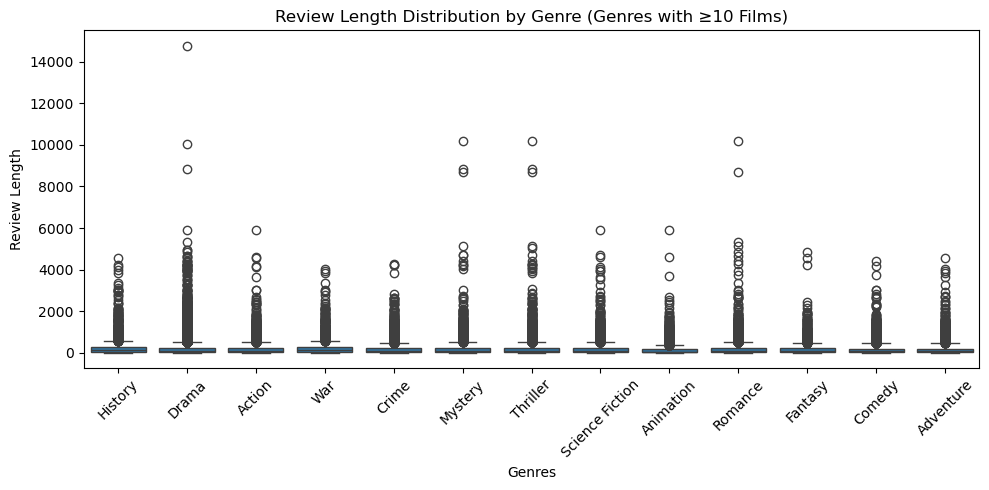

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    data=genre_df[genre_df["Genres"].isin(valid_genres)],
    x="Genres",
    y="review_length"
)

plt.ylabel("Review Length")
plt.xlabel("Genres")
plt.title("Review Length Distribution by Genre (Genres with ≥10 Films)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

After excluding genres represented by fewer than 10 films, differences in review length remain visible across genres.

History and War films are associated with the longest median reviews, whereas Animation, Adventure, and Comedy films tend to receive the shortest.

However, substantial variation exists within each genre. This suggests that genre may help explain some review-length differences, but it is unlikely to be the sole factor shaping reviewer behavior.

#### **Review Length by Spoken Language**

In [112]:
import ast

language_df = final_dataset.copy()

language_df["Spoken_languages"] = (
    language_df["Spoken_languages"]
    .apply(ast.literal_eval)
)

language_df = language_df.explode("Spoken_languages")

In [113]:
language_movie_counts = (
    language_df.groupby("Spoken_languages")["Movie"]
    .nunique()
    .sort_values(ascending=False)
)

language_movie_counts

Spoken_languages
English                             125
French                               36
Japanese                             35
Italian                              23
German                               22
Spanish                              20
Russian                              11
Latin                                 9
Swedish                               8
Chinese                               6
No spoken language                    5
Cantonese                             5
Arabic                                4
Korean                                3
Portuguese                            3
Turkish                               3
Yiddish                               2
Persian (Farsi)                       2
Hindi                                 2
Danish                                2
Czech                                 2
Hebrew (modern)                       2
Polish                                2
Hungarian                             2
Belarusian             

In [114]:
valid_languages = language_movie_counts[language_movie_counts >= 5].index

In [115]:
language_length = (
    language_df[language_df["Spoken_languages"].isin(valid_languages)]
    .groupby("Spoken_languages")["review_length"]
    .median()
    .sort_values(ascending=False)
)

language_length

Spoken_languages
Russian               117.0
Swedish               108.5
German                103.0
Chinese                97.5
Japanese               95.0
No spoken language     88.5
Italian                85.0
French                 80.5
English                72.0
Spanish                68.0
Cantonese              67.0
Latin                  64.0
Name: review_length, dtype: float64

In [116]:
language_summary = pd.DataFrame({
    "num_films": language_movie_counts[language_movie_counts >= 5],
    "median_length": language_length
})

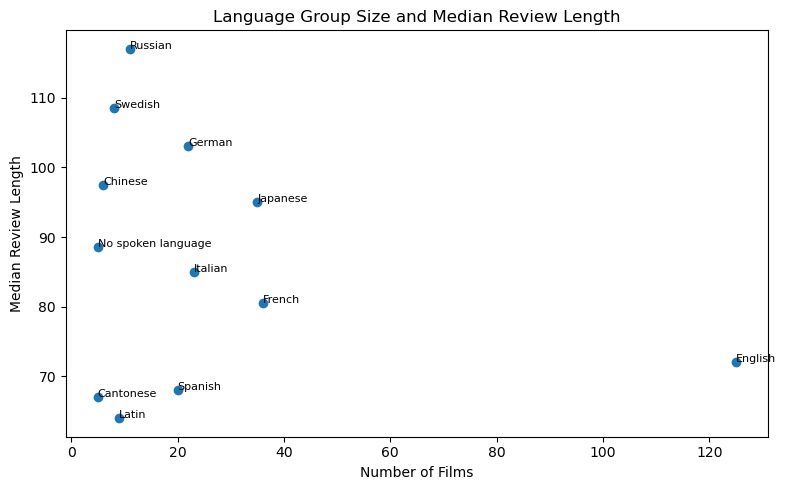

In [117]:
plt.figure(figsize=(8,5))

plt.scatter(
    language_summary["num_films"],
    language_summary["median_length"]
)

for language in language_summary.index:
    plt.annotate(
        language,
        (
            language_summary.loc[language, "num_films"],
            language_summary.loc[language, "median_length"]
        ),
        fontsize=8
    )

plt.xlabel("Number of Films")
plt.ylabel("Median Review Length")
plt.title("Language Group Size and Median Review Length")

plt.tight_layout()
plt.show()

Although differences in review length can be observed across language groups, these patterns should be interpreted cautiously because language representation is uneven within the dataset.

English-language films account for the largest share of the Top 250 dataset, while most other language groups are represented by substantially fewer films. However, the scatter plot suggests that review length differences are not simply a result of group size. Several non-English language groups, including Japanese, German, and Russian-language films, are associated with relatively long median reviews despite having fewer films represented in the dataset.

Overall, spoken language appears to be associated with some variation in review length, but no clear relationship emerges between the number of films in a language group and the length of reviews. As with genre, language may contribute to review-writing patterns, although additional factors are likely involved.

### **Word Frequency Analysis**

To better understand the content of Letterboxd reviews, this section examines the most frequently used words across the review corpus.

Because common function words (e.g., "the", "and", "of") dominate natural language, stopwords are removed before calculating word frequencies. The resulting distribution highlights the themes and concepts most commonly discussed by reviewers.

In [118]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\36043\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [119]:
from collections import Counter
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words("english"))


custom_stopwords = {"film", "films", "movie", "movies", "cinema", "good", "great", "bad", "better", "best", "worst", "favorite", "favourite", "like", "love", "liked", "loved", "think", "thought", "feel", "felt", "really", "very", "quite", "much", "still", "well", "also", "even", "just", "one", "something", "someone", "anything", "everything", "watch", "watched", "watching", "see", "seen", "would", "could", "should", "get", "got", "made", "make", "time", "times", "first", "last", "ever", "never", "que", "way", "every", "know", "many", "two", "say", "always", "makes", "man", "character", "characters", "long", "years", "little", "yet", "back", "though"}

stop_words = stop_words.union(custom_stopwords)

all_words = []

for review in final_dataset["Review"]:
    
    words = re.findall(r"\b[a-z]+\b", review.lower())

    words = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    all_words.extend(words)

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["word", "count"]
)

top_words

,word,count
0,life,22941
1,story,19542
2,people,15101
3,world,14282
4,scene,11490
5,work,10527
6,end,9954
7,war,9159
8,beautiful,8595
9,perfect,8426


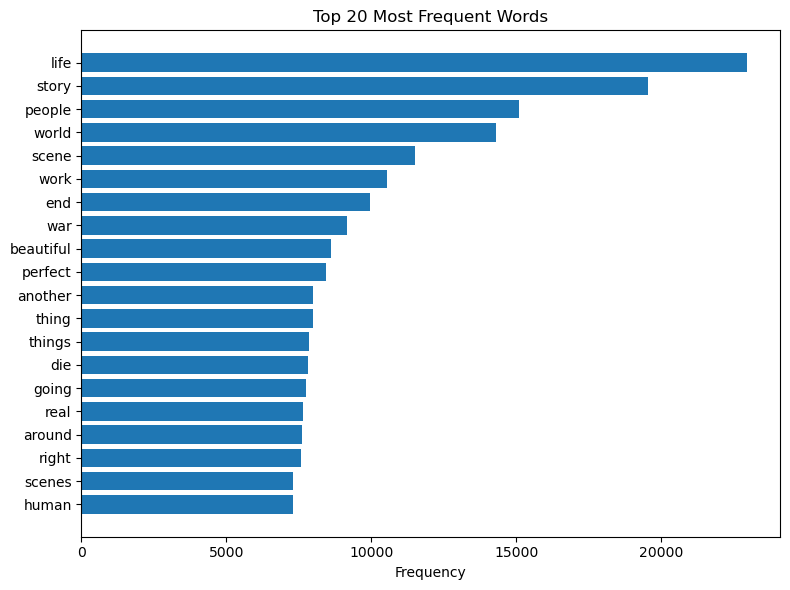

In [120]:
plt.figure(figsize=(8,6))

plt.barh(
    top_words["word"][::-1],
    top_words["count"][::-1]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")

plt.tight_layout()
plt.show()

After removing common English stopwords and domain-specific review vocabulary such as *film* and *movie*, several recurring themes emerge from the most frequently used words.

Terms such as *life*, *people*, *human*, and *world* suggest that reviewers often engage with films through reflections on human experience and broader social themes. At the same time, words such as *story*, *scene*, and *end* indicate sustained attention to narrative structure and cinematic storytelling.

Interestingly, evaluative terms such as *beautiful* and *perfect* also remain among the most frequent words, reflecting the tendency of reviewers to combine critical interpretation with expressions of aesthetic appreciation.

**Overall, the results suggest that reviews within the Letterboxd Top 250 community extend beyond simple judgments of quality. Instead, many reviewers appear to engage with films through thematic interpretation, personal reflection, and discussion of narrative meaning.**


### **Sentiment Analysis**

This section applies **VADER (Valence Aware Dictionary and sEntiment Reasoner)**
to examine how sentiment is distributed across the corpus and whether it varies 
by genre, film, and review length.

In [121]:
%pip install vadersentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [122]:
analyzer = SentimentIntensityAnalyzer()

example = final_dataset["Review"].iloc[0]
print(analyzer.polarity_scores(example))

{'neg': 0.12, 'neu': 0.72, 'pos': 0.16, 'compound': 0.8901}


#### **Overall Sentiment Distribution**

In [123]:
final_dataset["vader_compound"] = final_dataset["Review"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

final_dataset["vader_compound"].describe()

count    67574.000000
mean         0.375803
std          0.650389
min         -1.000000
25%          0.000000
50%          0.636900
75%          0.954700
max          1.000000
Name: vader_compound, dtype: float64

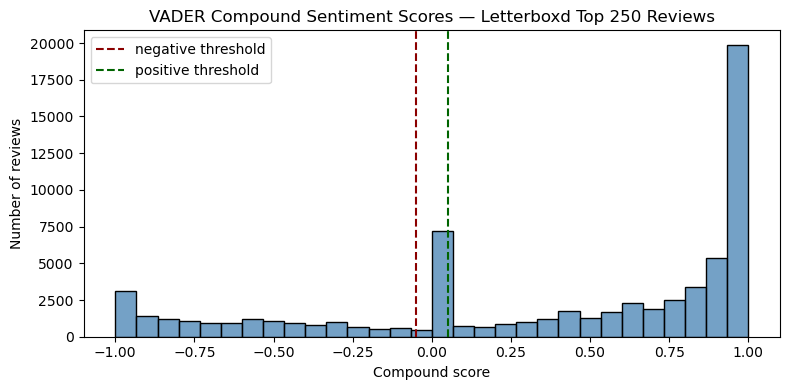

In [124]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=final_dataset,
    x="vader_compound",
    bins=30,
    color="steelblue",
)
plt.axvline(-0.05, color="darkred", linestyle="--", label="negative threshold")
plt.axvline(0.05, color="darkgreen", linestyle="--", label="positive threshold")
plt.title("VADER Compound Sentiment Scores — Letterboxd Top 250 Reviews")
plt.xlabel("Compound score")
plt.ylabel("Number of reviews")
plt.legend()
plt.tight_layout()
plt.show()

The distribution of VADER compound scores across the corpus reveals a pronounced 
positive skew. The mean compound score is 0.376, and the majority of reviews fall 
above the positive threshold of 0.05. This pattern is consistent with the nature 
of the corpus: reviews drawn from Letterboxd's Top 250 list represent films that 
users have chosen to engage with deeply, and the community's overall orientation 
toward these canonical works is strongly appreciative.

However, a notable cluster of reviews scores near 0.00 (neutral), and a smaller 
but visible proportion of reviews receives negative compound scores. This suggests 
that even within a community of film enthusiasts, not all engagement with highly 
regarded films is uniformly positive.

#### **Sentiment by Genre**

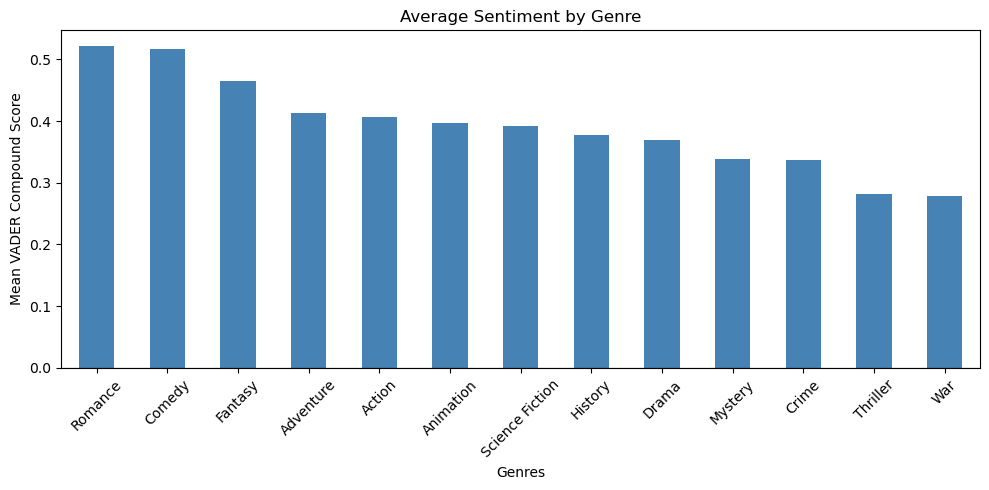

In [125]:
movie_sentiment = (
    final_dataset
    .groupby("Movie")["vader_compound"]
    .mean()
    .reset_index()
    .rename(columns={"vader_compound": "vader_compound"})
)

genre_df = genre_df.merge(
    movie_sentiment,
    on="Movie",
    how="left"
)

sentiment_genre = (
    genre_df[genre_df["Genres"].isin(valid_genres)]
    .groupby("Genres")["vader_compound"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sentiment_genre.plot.bar(color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Mean VADER Compound Score")
plt.title("Average Sentiment by Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sentiment scores vary meaningfully across genres. Romance and Comedy films receive 
the highest average sentiment scores (approximately 0.52), while War and Thriller 
films receive the lowest (approximately 0.28). 

This pattern is particularly interesting when read alongside the review length 
findings from the previous section. History and War films were associated with the 
longest reviews, yet they receive comparatively lower sentiment scores. This 
suggests that longer reviews in this corpus do not necessarily reflect stronger 
positive affect. Instead, they may reflect a more analytical or reflective mode of 
engagement — one in which reviewers invest more words precisely because the 
subject matter resists easy emotional resolution.

#### **Sentiment by Film**

In [126]:
sentiment_by_film = (
    final_dataset
    .groupby("Movie")["vader_compound"]
    .mean()
    .sort_values(ascending=False)
)

print("Most positively reviewed films:")
print(sentiment_by_film.head(10))
print("\nLeast positively reviewed films:")
print(sentiment_by_film.tail(10))

Most positively reviewed films:
Movie
a-matter-of-life-and-death    0.712366
tampopo                       0.668392
city-lights                   0.657268
paper-moon                    0.655632
some-like-it-hot              0.643135
children-of-paradise          0.641381
cinema-paradiso               0.639622
sherlock-jr                   0.634899
millennium-actress            0.629542
wings-of-desire               0.626304
Name: vader_compound, dtype: float64

Least positively reviewed films:
Movie
apocalypse-now               0.068172
the-cremator                 0.060113
incendies                    0.051919
an-elephant-sitting-still    0.017316
m                           -0.003818
the-battle-of-algiers       -0.021125
the-hunt-2012               -0.039905
cure                        -0.164388
grave-of-the-fireflies      -0.165936
come-and-see                -0.369472
Name: vader_compound, dtype: float64


At the film level, the most positively reviewed works tend to be romantic or 
warmly nostalgic in tone: *A Matter of Life and Death*, *Tampopo*, *City Lights*, 
*Paper Moon*, and *Cinema Paradiso* rank among the highest. These are films 
frequently described in terms of joy, beauty, and emotional warmth.

By contrast, films receiving the lowest average sentiment scores include 
*Apocalypse Now*, *The Battle of Algiers*, *An Elephant Sitting Still*, and 
*Grave of the Fireflies* — works associated with war, grief, political violence, 
and existential despair. The alignment between subject matter and sentiment score 
suggests that VADER is partially capturing the emotional register of the films 
being described, not only the reviewer's personal evaluation.

#### **Review Length and Sentiment**


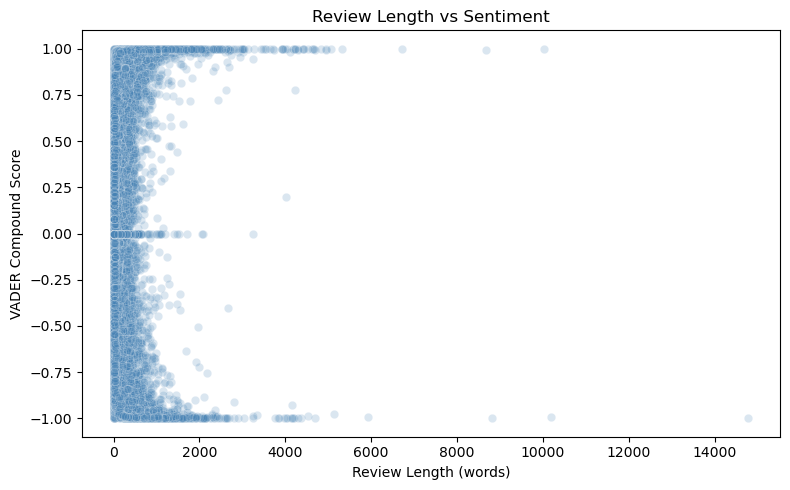

,review_length,vader_compound
review_length,1.000000,0.085643
vader_compound,0.085643,1.000000


In [127]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=final_dataset,
    x="review_length",
    y="vader_compound",
    alpha=0.2,
    color="steelblue",
)
plt.xlabel("Review Length (words)")
plt.ylabel("VADER Compound Score")
plt.title("Review Length vs Sentiment")
plt.tight_layout()
plt.show()


final_dataset[["review_length", "vader_compound"]].corr()

The correlation between review length and sentiment compound score is weak 
(r = 0.086), indicating that longer reviews are not systematically more or less 
positive than shorter ones. 

Taken together, these findings suggest that sentiment and engagement depth are 
distinct dimensions of reviewing behavior in this community. Reviewers who write 
at length about War or History films are not necessarily writing negatively — they 
are writing *carefully*, engaging with difficult material in a way that resists 
the enthusiastic shorthand common in shorter reviews.

#### **Sentiment Analysis Reflection**
The sentiment analysis also highlights an important **limitation** of computational methods. Several films with relatively low sentiment scores, such as Grave of the Fireflies and Come and See, are widely regarded as masterpieces within the Top 250 community. This suggests that sentiment scores may capture the emotional language used to describe a film rather than the reviewer's overall appreciation of it. In addition, tools such as VADER may struggle to interpret irony, sarcasm, and other forms of nuanced expression that are common in online review culture.

### **Topic Modelling**

In [128]:
print("reviews under 20 words:", (final_dataset["review_length"] < 20).mean())
print("reviews under 50 words:", (final_dataset["review_length"] < 50).mean())

reviews under 20 words: 0.22650723651108415
reviews under 50 words: 0.3938349069168615


In [129]:
%pip install pyLDAvis

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import pyLDAvis

Note: you may need to restart the kernel to use updated packages.


#### **Data Preparation for Topic Modeling**

Several preprocessing decisions were made before fitting the topic model.

**First, only reviews of 50 words or more were retained.** Approximately 39% of 
reviews in the corpus fall below this threshold. Because LDA identifies topics 
from patterns of word co-occurrence, very short texts provide insufficient 
context for meaningful topic assignment.

**Second, reviews were filtered to retain only those in which more than 70% of 
characters are Latin script.** This removed 777 non-English reviews from the 
modeling corpus, reducing noise from Portuguese, Spanish, German, and Arabic 
texts. Additional non-English function words identified in an initial model run 
were added to the stopword list before the final model was fitted.

These choices reflect a broader methodological caution: topic modeling results 
are shaped by preprocessing decisions, and different choices would likely produce 
different topics.

In [130]:
lda_corpus = final_dataset[
    final_dataset["review_length"] >= 50
]["Review"].copy()

print(f"Reviews used for topic modeling: {len(lda_corpus)}")
print(f"Proportion of full corpus: {len(lda_corpus)/len(final_dataset):.2%}")

Reviews used for topic modeling: 40961
Proportion of full corpus: 60.62%


In [131]:
lda_corpus_en = lda_corpus[
    lda_corpus.str.count(r'[a-zA-Z]') / lda_corpus.str.len() > 0.7
]

print(f"English reviews: {len(lda_corpus_en)}")
print(f"Dropped: {len(lda_corpus) - len(lda_corpus_en)}")

# Additional stopwords identified from non-English reviews
extra_stopwords = {
    # German
    "die", "und", "der", "den", "das", "ein", "eine", "ist", "zu", "ich",

    # Spanish
    "de", "la", "el", "en", "un", "una", "se", "como",

    # Portuguese
    "uma", "um", "em", "da", "do", "para"
}

stop_words.update(extra_stopwords)

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=20,
    max_features=1000,
    ngram_range=(1, 1),
    stop_words=list(stop_words),
)

dtm = vectorizer.fit_transform(lda_corpus_en)
vocab = vectorizer.get_feature_names_out()

print(f"DTM shape: {dtm.shape}")

English reviews: 40184
Dropped: 777
DTM shape: (40184, 1000)


In [132]:
n_topics = 4

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="online",
    random_state=42,
    n_jobs=-1
)

lda.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",4
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [133]:
import pandas as pd

def get_top_words(model, feature_names, n_top_words=12):
    topic_rows = []
    for topic_idx, topic in enumerate(model.components_, start=1):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_terms = [feature_names[i] for i in top_indices]
        topic_rows.append({
            "topic": f"Topic {topic_idx}",
            "top_words": ", ".join(top_terms),
        })
    return pd.DataFrame(topic_rows)

topic_words = get_top_words(lda, vocab, n_top_words=12)
topic_words

,topic,top_words
0,Topic 1,"life, people, things, want, go, going, us, end..."
1,Topic 2,"story, performances, performance, scene, perfe..."
2,Topic 3,"es, por, com, filme, não, con, mais, le, los, ..."
3,Topic 4,"life, world, human, us, story, war, work, tark..."


In [134]:
for _, row in topic_words.iterrows():
    print(f"\n{row['topic']}:")
    print(row['top_words'])


Topic 1:
life, people, things, want, go, going, us, end, thing, world, right, day

Topic 2:
story, performances, performance, scene, perfect, scenes, work, cinematography, masterpiece, score, amazing, incredible

Topic 3:
es, por, com, filme, não, con, mais, le, los, di, lo, su

Topic 4:
life, world, human, us, story, war, work, tarkovsky, within, art, death, sense


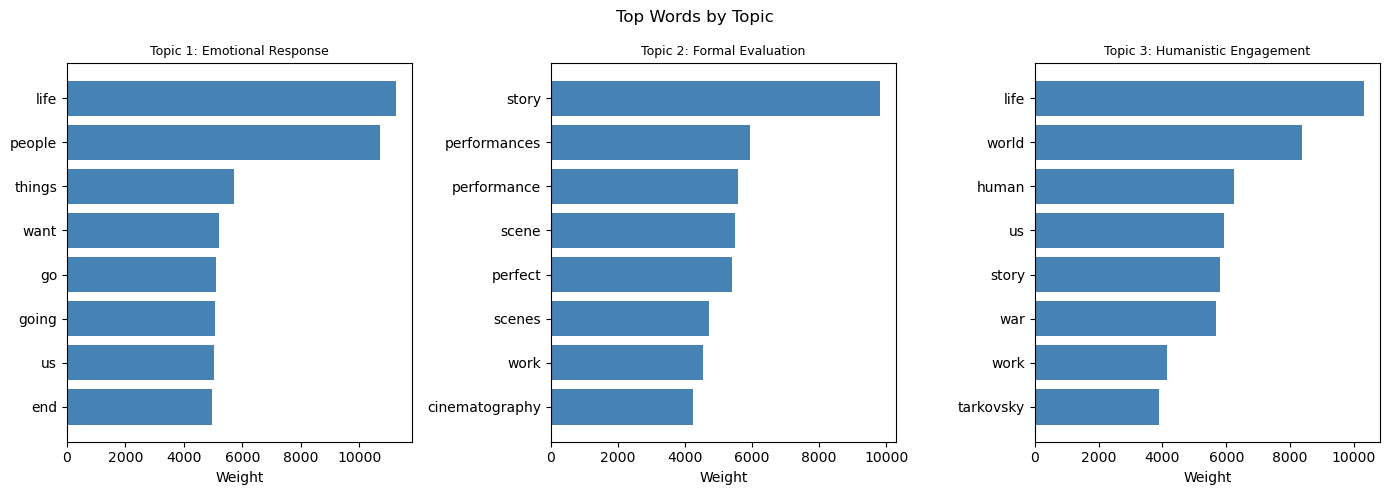

In [135]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
topic_labels = ["Topic 1: Emotional Response", 
                "Topic 2: Formal Evaluation", 
                "Topic 3: Humanistic Engagement"]
topic_indices = [0, 1, 3]  

for ax, topic_idx, label in zip(axes, topic_indices, topic_labels):
    top_n = 8
    weights = lda.components_[topic_idx]
    top_i = weights.argsort()[::-1][:top_n]
    top_w = [vocab[i] for i in top_i]
    top_v = weights[top_i]
    
    ax.barh(top_w[::-1], top_v[::-1], color="steelblue")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Weight")

plt.suptitle("Top Words by Topic", fontsize=12)
plt.tight_layout()
plt.show()

#### **Topic Modelling Result Analysis**

**Three of the four fitted topics are visualized above.** Topic 3 was excluded from 
interpretation and visualization because it consisted primarily of non-English 
function words (Portuguese, Spanish) that remained in the corpus despite 
preprocessing. This is a known limitation of bag-of-words topic modeling applied 
to multilingual corpora.

The three interpretable topics suggest distinct modes of engagement within the 
Letterboxd Top 250 community:

**Topic 1 — Emotional and Personal Response**
> *life, people, things, want, going, us, end, world, right, day*

This topic is characterized by everyday, conversational language centered on 
lived experience. Reviewers in this cluster appear to engage with films through 
personal reflection, describing how a film made them feel or what it reminded 
them of. The informal register suggests this mode is common among shorter, 
reactive reviews.

**Topic 2 — Formal and Technical Evaluation**
> *story, performances, scene, cinematography, score, masterpiece, amazing, incredible*

This topic reflects a more structured, evaluative vocabulary. Terms such as 
*cinematography*, *score*, and *performances* indicate attention to craft, while 
words like *masterpiece* and *perfect* reflect the community's tendency toward 
strong aesthetic judgments. This topic likely captures longer, more deliberate 
critical writing.

**Topic 3 — Humanistic and Philosophical Engagement**
> *world, human, war, tarkovsky, within, art, death, sense*

The appearance of *Tarkovsky* alongside *art*, *human*, and *death* is 
particularly striking. This topic suggests a subset of reviewers who engage with 
film as a philosophical medium, drawing on auteur references and broader 
questions about mortality, meaning, and the human condition. This aligns with 
the earlier finding that art-house and slow-cinema films tend to generate 
substantially longer reviews.

These three modes — emotional reaction, formal evaluation, and philosophical 
reflection — suggest that reviewing culture in the Letterboxd Top 250 community 
is not uniform. Different films, and different reviewers, draw on distinct 
rhetorical traditions when writing about cinema.

## **Conclusion**

This project examined linguistic patterns, sentiment expression, and reviewing 
culture in Letterboxd's Top 250 film community through a series of computational 
analyses applied to a corpus of 67,574 reviews across 195 films.

Several patterns emerged consistently across the analyses.

**Review length is shaped by film characteristics, not rating.** Ratings alone 
explain little variation in how much reviewers write. Instead, film-level factors 
— particularly genre and cinematic tradition — appear to drive engagement depth. 
Art-house and slow-cinema works such as *Satantango*, *Stalker*, and *Andrei 
Rublev* consistently attract longer reviews, while more mainstream titles receive 
shorter ones.

**Sentiment and engagement depth are distinct dimensions.** History and War films 
generate the longest reviews but receive comparatively lower sentiment scores. 
Romance and Comedy films receive the highest sentiment scores but shorter reviews. 
The weak correlation between review length and sentiment (r = 0.086) confirms 
that writing more does not mean writing more positively — longer reviews appear 
to reflect a more analytical mode of engagement rather than stronger appreciation.

**Three distinct modes of reviewing coexist in the community.** Topic modeling 
identified emotional-personal responses, formal-technical evaluations, and 
humanistic-philosophical reflections as recurring patterns. The appearance of 
*Tarkovsky* as a topic keyword alongside *art*, *human*, and *death* suggests 
that a subset of reviewers engage with film as a philosophical medium, a pattern 
consistent with the longer-review tendency observed among art-house titles.

**Taken together, these findings suggest that the Letterboxd Top 250 community 
is not a uniform fan space.** It contains multiple reviewing cultures — 
enthusiastic appreciation, critical evaluation, and serious humanistic inquiry 
— that coexist within the same platform and corpus.

### **Limitations**

Several limitations should be noted. VADER was designed for general social media 
text and may not accurately capture the nuanced language of film criticism, 
including irony and understatement. The metadata merge covered only 195 of the 
250 films, potentially introducing selection bias. Topic modeling results are 
sensitive to preprocessing choices, and the presence of non-English reviews 
required additional filtering that may have excluded meaningful perspectives. 
Future work could incorporate human annotation, multilingual sentiment tools, 
and a more complete metadata source to address these constraints.

## **Brief Reflection on the Project**

This project involved several unexpected turns that ultimately shaped both its 
direction and its outcomes.

**On research design and data constraints.** The original plan was to compare 
reviewing practices between IMDb and Letterboxd. In retrospect, this goal was 
set before a close examination of the datasets. The IMDb dataset contains only 
review text and sentiment labels with no film-level metadata, while the 
Letterboxd dataset is organized around specific films from the Top 250 list. 
This structural mismatch which only became apparent during exploratory analysis 
made a direct comparison methodologically difficult to defend. The pivot to a 
single-corpus study required bringing in an additional metadata dataset and 
redesigning the research questions mid-project. This experience highlighted how 
much data structure shapes what questions are actually answerable, and how 
important it is to explore datasets carefully before committing to a research 
design.

**On methods and learning.** The analyses in this project were largely modeled 
on methods introduced in class: word frequency analysis, sentiment scoring with 
VADER, and topic modeling with LDA. Applying these tools to a self-chosen dataset 
was a different experience from working through prepared exercises. Small 
decisions that seemed straightforward in class like choosing stopwords, filtering 
by review length, handling non-English text turned out to require careful 
thought in practice. The multilingual nature of the Letterboxd corpus, for 
instance, was not anticipated and required an additional filtering step that was 
not part of the original plan.

**On findings.** Many of the results confirm what might be intuitively expected: 
art-house films receive longer reviews, War films score lower on sentiment, 
Romance films score higher. In that sense, the findings are not surprising. But 
that is also part of what makes them meaningful: computational methods 
confirmed and quantified patterns that film culture would predict, while also 
revealing some nuances, such as the weak relationship between review length and 
sentiment, and the coexistence of distinct rhetorical modes within a single 
online community. The value of the exercise was less in discovering the 
unexpected and more in learning to ask answerable questions, handle messy real-
world data, and interpret results with appropriate caution.